# Figure 6.4-3 &mdash; Pressure&ndash;volume diagram for oxygen (Peng&ndash;Robinson EOS)

This notebook recreates **Figure 6.4-3** of Illustration 6.4-1, *Making of a
Thermodynamic Properties Chart*. It plots isotherms of oxygen in the
$P$&ndash;$\underline{V}$ plane from the Peng&ndash;Robinson equation of state on
log&ndash;log axes and adds the vapor&ndash;liquid two-phase region (the
saturation envelope and horizontal tie lines) computed from the equal-fugacity
condition.

The isotherms above the critical temperature are exactly the Chapter 6
calculation of Illustration 6.4-1. The two-phase envelope and the sub-critical
tie lines use the fugacity condition developed in Chapter 7 (see Sec. 7.5); the
construction here is the same one used for the van der Waals fluid in
**Figure 7.3-4**.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering
Thermodynamics*.

Eric Furst
July 2026

## Generalized Peng&ndash;Robinson equation of state

The generalized Peng&ndash;Robinson equation of state is

$$ P = \frac{RT}{\underline{V}-b} - \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

with

$$ b = 0.07780 \frac{RT_c}{P_c} \tag{Eq. 6.7-2}$$
$$ a(T) = 0.45724 \frac{R^2T_c^2}{P_c}\,\alpha(T) \tag{Eq. 6.7-1}$$
$$ \sqrt{\alpha} = 1 + \kappa \left( 1- \sqrt{T/T_c} \right) \tag{Eq. 6.7-3}$$
$$ \kappa = 0.37464 + 1.54226\,\omega - 0.26992\,\omega^2 \tag{Eq. 6.7-4}$$

Given $\underline{V}$ and $T$, computing $P$ is direct. Given $P$ and $T$, the
molar volume follows from the cubic in the compressibility factor
$Z = P\underline{V}/RT$,

$$ Z^3 + \alpha Z^2 + \beta Z + \gamma = 0 \tag{Eq. 6.4-4}$$

with (SIS Table 6.4-3)

$$ \alpha = -1 + B, \qquad \beta = A - 3B^2 - 2B, \qquad \gamma = -AB + B^2 + B^3 $$
$$ A = \frac{aP}{(RT)^2}, \qquad B = \frac{bP}{RT} $$

In [61]:
"""
Generalized Peng-Robinson EOS
PR_pressure : pressure (Pa) given V, T
PR_volume   : all real molar-volume roots (m^3/mol) given P, T
"""
import numpy as np
from scipy import constants
from numpy.polynomial import Polynomial

R = constants.R  # gas constant, J/(mol K)

TO_KELVIN = 273.15
BAR = 1e5          # Pa per bar
M3_PER_KMOL = 1e3  # (m^3/kmol) per (m^3/mol)

# Critical properties and acentric factor for oxygen (SIS Table 6.6-1).
# omega = 0.021 reproduces the book value kappa = 0.4069 used in Illustration 6.4-1.
Pc = 5.046e6   # Pa
Tc = 154.6     # K
omega = 0.021


def calc_b(Pc, Tc):
    return 0.07780 * R * Tc / Pc


def calc_a(T, Pc, Tc, omega):
    kappa = 0.37464 + 1.54226 * omega - 0.26992 * omega**2
    sqrtalpha = 1 + kappa * (1 - np.sqrt(T / Tc))
    return 0.45724 * R**2 * Tc**2 / Pc * sqrtalpha**2


def PR_pressure(V, T, Pc, Tc, omega):
    a = calc_a(T, Pc, Tc, omega)
    b = calc_b(Pc, Tc)
    return R * T / (V - b) - a / (V * (V + b) + b * (V - b))


def PR_volume(P, T, Pc, Tc, omega):
    """Return the real molar-volume roots (m^3/mol), ascending."""
    a = calc_a(T, Pc, Tc, omega)
    b = calc_b(Pc, Tc)
    A = a * P / R**2 / T**2
    B = b * P / R / T

    alpha = -1 + B
    beta = A - 3 * B**2 - 2 * B
    gamma = -A * B + B**2 + B**3

    # coefficients in increasing order: c0 + c1 Z + c2 Z^2 + Z^3
    roots = Polynomial([gamma, beta, alpha, 1]).roots()
    real_roots = np.sort(roots.real[np.abs(roots.imag) < 1e-9])
    return real_roots * R * T / P


kappa = 0.37464 + 1.54226 * omega - 0.26992 * omega**2
print(f"oxygen: Tc = {Tc} K, Pc = {Pc/1e5:.2f} bar, kappa = {kappa:.4f}")


oxygen: Tc = 154.6 K, Pc = 50.46 bar, kappa = 0.4069


## Fugacity and the two-phase region

To locate the vapor&ndash;liquid coexistence line we equate the liquid and vapor
fugacities at each temperature. For the Peng&ndash;Robinson equation of state the
fugacity coefficient is

$$ \ln\frac{f}{P} = (Z-1) - \ln(Z-B) - \frac{A}{2\sqrt{2}\,B}\,
   \ln\!\left[\frac{Z+(1+\sqrt{2})B}{Z+(1-\sqrt{2})B}\right] $$

The saturation pressure $P^{\mathrm{sat}}(T)$ is the pressure at which
$\ln(f^L/P) = \ln(f^V/P)$, using the smallest (liquid) and largest (vapor)
compressibility roots.

This is calculation that is described further in Chapter 7.

In [62]:
SQRT2 = np.sqrt(2.0)


def PR_lnphi_from_Z(Z, A, B):
    """ln of the fugacity coefficient given a compressibility root."""
    return Z - 1 - np.log(Z - B) - A / (2 * SQRT2 * B) * np.log(
        (Z + (1 + SQRT2) * B) / (Z + (1 - SQRT2) * B))


def PR_roots_Z(P, T, Pc, Tc, omega):
    a = calc_a(T, Pc, Tc, omega)
    b = calc_b(Pc, Tc)
    A = a * P / R**2 / T**2
    B = b * P / R / T
    alpha = -1 + B
    beta = A - 3 * B**2 - 2 * B
    gamma = -A * B + B**2 + B**3
    roots = Polynomial([gamma, beta, alpha, 1]).roots()
    # keep roots that are real to within a tolerance scaled to their magnitude;
    # near the critical point the three real roots crowd together and pick up
    # tiny numerical imaginary parts, so a fixed 1e-9 cut would drop them early
    tol = 1e-6 * np.maximum(1.0, np.abs(roots.real))
    Z = np.sort(roots.real[np.abs(roots.imag) < tol])
    return Z, A, B


### Saturation pressure at a given temperature

The saturation pressure is where the residual $\ln(f^L/P) - \ln(f^V/P)$ vanishes.
A Newton iteration works well away from the critical point, but it needs a good
starting guess and, as $T \to T_c$, the van der Waals loop it must sit inside
shrinks to a point — so Newton easily steps outside the loop and fails. Instead
we **bracket** the root: for $T < T_c$ the isotherm has a loop with a local
pressure maximum (the liquid spinodal) and a local minimum (the vapor spinodal),
and $P^{\mathrm{sat}}$ always lies between them. Bracketing between those two
pressures and solving with bisection (`brentq`) stays robust right up to the
critical point. A quick test at $-175\,^{\circ}$C should give about 2 bar,
matching the lowest tie line in Figure 6.4-3.

In [63]:
from scipy.optimize import brentq


def loop_pressure_bounds(T, n=4000):
    """Local max (liquid spinodal) and min (vapor spinodal) pressures of the
    sub-critical isotherm loop. Returns None if the loop has vanished (T >= Tc)."""
    b = calc_b(Pc, Tc)
    V = np.logspace(np.log10(1.001 * b), np.log10(0.02), n)
    P = PR_pressure(V, T, Pc, Tc, omega)
    turns = np.where(np.diff(np.sign(np.diff(P))) != 0)[0]  # dP/dV sign changes
    if len(turns) < 2:
        return None
    return P[turns].min(), P[turns].max()


def Psat(T):
    """Saturation pressure (Pa) at T (K), found by bracketing between the
    spinodal pressures and solving ln(f^L) = ln(f^V) with bisection."""
    bounds = loop_pressure_bounds(T)
    if bounds is None:
        return None
    P_lo = max(1.0, bounds[0]) * 1.0001   # just inside the loop
    P_hi = bounds[1] * 0.9999

    def residual(P):
        Z, A, B = PR_roots_Z(P, T, Pc, Tc, omega)
        return PR_lnphi_from_Z(Z.min(), A, B) - PR_lnphi_from_Z(Z.max(), A, B)

    if residual(P_lo) * residual(P_hi) > 0:
        return None
    return brentq(residual, P_lo, P_hi, xtol=1.0, rtol=1e-12, maxiter=200)


T_test = -175 + TO_KELVIN
print(f"P_sat(-175 C) = {Psat(T_test)/BAR:.3f} bar")


P_sat(-175 C) = 2.193 bar


## Build the saturation envelope

We sweep temperature from low $T$ up toward $T_c$, solving for the saturation
pressure at each step and recording the saturated-liquid and saturated-vapor
molar volumes. The temperature grid is **clustered toward $T_c$** (geometric
spacing in $T_c - T$) so the points are dense exactly where the envelope turns
over — the bracketed solver stays reliable to within about 0.2 K of $T_c$. Once
the loop finally vanishes we close the curve with the **exact critical point**
$(\underline{V}_c, P_c)$, so both branches meet cleanly at the top.

In [64]:
import pandas as pd

# grid clustered toward Tc: spacing shrinks near the critical point
frac = np.geomspace(2e-3, 1.0, 500)
T_list = np.sort(Tc - (Tc - 60.0) * frac)   # 60 K ... just below Tc

rows = []
for T in T_list:
    ps = Psat(T)
    if ps is None:
        continue
    Z, A, B = PR_roots_Z(ps, T, Pc, Tc, omega)
    if len(Z) < 2 or (Z.max() - Z.min()) < 1e-7:   # roots merged -> at the top
        continue
    vL = Z.min() * R * T / ps  # m^3/mol
    vV = Z.max() * R * T / ps
    rows.append({"T": T, "P": ps, "vL": vL, "vV": vV})

# close the envelope exactly at the critical point (vL = vV = Vc)
Vc = float(np.mean(PR_volume(Pc, Tc, Pc, Tc, omega)))
rows.append({"T": Tc, "P": Pc, "vL": Vc, "vV": Vc})

envelope = pd.DataFrame(rows).sort_values("T").reset_index(drop=True)
print(f"{len(envelope)} points; approaches within "
      f"{Tc - envelope['T'].iloc[-2]:.2f} K of Tc "
      f"(top point {envelope['P'].iloc[-2]/BAR:.2f} bar, Pc = {Pc/BAR:.2f} bar)")
envelope.tail()


501 points; approaches within 0.19 K of Tc (top point 50.11 bar, Pc = 50.46 bar)


,T,P,vL,vV
496,154.403597,5.009856e+06,0.000071,0.000087
497,154.406028,5.010308e+06,0.000071,0.000087
498,154.408429,5.010754e+06,0.000071,0.000087
499,154.410800,5.011195e+06,0.000071,0.000087
500,154.600000,5.046000e+06,0.000082,0.000082


## Figure 6.4-3

Finally we assemble the figure: the supercritical isotherms as before, the
sub-critical isotherms with their van der Waals loops replaced by horizontal tie
lines, the saturation envelope, and the critical point. The result reproduces
Figure 6.4-3. A high-resolution PDF is written to `pdf/Fig_6.4-3.pdf`.

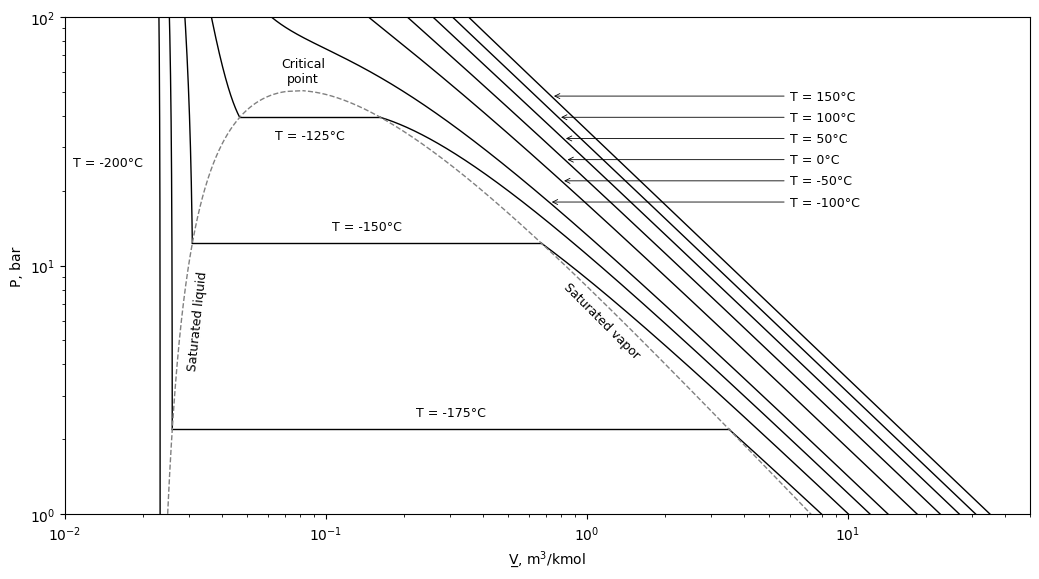

In [87]:
import os

# aspect ratio and axes limits match Fig. 6.4-3 in the 5th edition
fig, ax = plt.subplots(figsize=(10.5, 5.9))
b = calc_b(Pc, Tc)
BLACK = "black"


def isotherm_branch(T, V_lo, V_hi, n=2000):
    V = np.logspace(np.log10(V_lo), np.log10(V_hi), n)
    return V, PR_pressure(V, T, Pc, Tc, omega)


# --- supercritical isotherms (single-valued) ---
supercrit = [150, 100, 50, 0, -50, -100]
iso_curves = {}
for TC in supercrit:
    T = TC + TO_KELVIN
    V, P = isotherm_branch(T, 1.02 * b, 0.05)
    ax.plot(V * M3_PER_KMOL, P / BAR, "-", color=BLACK, lw=1)
    iso_curves[TC] = (V, P)

# temperature key: evenly spaced labels on the right, each joined to its isotherm
# by a horizontal arrow pointing left (as in the book)
P_key = np.logspace(np.log10(48), np.log10(18), len(supercrit))  # bar
V_text = 6.0                                                     # m^3/kmol
for TC, P_lab in zip(supercrit, P_key):
    V, P = iso_curves[TC]
    V_head = np.interp(P_lab * BAR, P[::-1], V[::-1])   # V where isotherm hits P_lab
    ax.annotate(f"T = {TC}°C",
                xy=(V_head * M3_PER_KMOL, P_lab), xycoords="data",
                xytext=(V_text, P_lab), textcoords="data",
                fontsize=9, va="center", ha="left",
                arrowprops=dict(arrowstyle="->", lw=0.6, color=BLACK))

# --- sub-critical isotherms: liquid branch + tie line + vapor branch ---
for TC in [-125, -150, -175, -200]:
    T = TC + TO_KELVIN
    ps = Psat(T)
    Z, A, B = PR_roots_Z(ps, T, Pc, Tc, omega)
    vL, vV = Z.min() * R * T / ps, Z.max() * R * T / ps

    VL, PL = isotherm_branch(T, 1.02 * b, vL)          # liquid branch
    VV, PV = isotherm_branch(T, vV, 0.5)               # vapor branch
    ax.plot(VL * M3_PER_KMOL, PL / BAR, "-", color=BLACK, lw=1)
    ax.plot(VV * M3_PER_KMOL, PV / BAR, "-", color=BLACK, lw=1)
    ax.plot([vL * M3_PER_KMOL, vV * M3_PER_KMOL], [ps / BAR, ps / BAR],
            "-", color=BLACK, lw=1)                     # horizontal tie line

    if TC == -200:
        continue  # its tie line lies below the plotted range; label the curve instead
    V_mid = np.sqrt(vL * vV)
    if ps / BAR > 25:   # -125 C: drop below the line to clear the envelope apex
        ax.text(V_mid * M3_PER_KMOL, ps / BAR * 0.9, f"T = {TC}\u00b0C", fontsize=9,
                ha="center", va="top")
    else:
        ax.text(V_mid * M3_PER_KMOL, ps / BAR * 1.1, f"T = {TC}\u00b0C", fontsize=9,
                ha="center", va="bottom")

# -200 C labels the steep near-vertical isotherm at the upper left
ax.text(0.0108, 26, "T = -200\u00b0C", fontsize=9, ha="left", va="center")

# --- saturation envelope (same black line as the isotherms) ---
ax.plot(envelope.vL * M3_PER_KMOL, envelope.P / BAR, "--", color="gray", lw=1)
ax.plot(envelope.vV * M3_PER_KMOL, envelope.P / BAR, "--", color="gray", lw=1)

# --- critical point (text only, as in the book) ---
ax.text(Vc * M3_PER_KMOL, 1.2*Pc / BAR, "Critical\npoint", fontsize=9, ha="center", va="center")

# --- saturated-liquid / saturated-vapor labels along the envelope ---
iL = (envelope.P / BAR - 6.0).abs().idxmin()
rowL = envelope.loc[iL]
ax.text(1.15*rowL.vL * M3_PER_KMOL, rowL.P / BAR, "Saturated liquid",
        rotation=84, rotation_mode="anchor", fontsize=9, ha="center", va="center")
iV = (envelope.P / BAR - 3.5).abs().idxmin()
rowV = envelope.loc[iV]
ax.text(0.5 * rowV.vV * M3_PER_KMOL, rowL.P / BAR, "Saturated vapor",
        rotation=-45, rotation_mode="anchor", fontsize=9, ha="center", va="center")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.01, 50)
ax.set_ylim(1.0, 100)
ax.set_xlabel("V\u0332, m$^3$/kmol")   # underbar V = molar volume (book notation)
ax.set_ylabel("P, bar")

os.makedirs("pdf", exist_ok=True)
plt.tight_layout()
plt.savefig("pdf/Fig_6.4-3.pdf", dpi=300, bbox_inches="tight")
plt.show()
